In [2]:
# Upload dataset and read it into a pandas DataFrame
%pip install pandas
import pandas as pd

path = r"C:\Users\ramir\OneDrive\TMU Capstone\HR-Employee-Attrition-Dataset.csv"
df = pd.read_csv(path)
df.head()

Note: you may need to restart the kernel to use updated packages.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [15]:
# Number of rows and columns
rows, cols = df.shape
print("Rows:", rows)
print("Columns:", cols)

Rows: 1470
Columns: 35


In [10]:
# Check data types of each column
df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [17]:
# Check missing values for each column
print(df.isnull().sum())
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_summary = pd.concat([missing_count, missing_percent], axis=1)
missing_summary.columns = ['missing_count', 'missing_percent']
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

print("Total missing values in dataset:", missing_count.sum())
missing_summary

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

,missing_count,missing_percent


In [18]:
# Check for missing/null values (uses existing variables: df, missing_count, missing_percent, missing_summary)
total_missing = missing_count.sum()
print("Total missing values:", total_missing)

if total_missing == 0:
    print("No missing/null values found in the dataset.")
else:
    print("\nMissing values by column:")
    display(missing_summary.sort_values('missing_count', ascending=False))
    print("\nSample rows with any missing values:")
    display(df[df.isnull().any(axis=1)].head())

Total missing values: 0
No missing/null values found in the dataset.


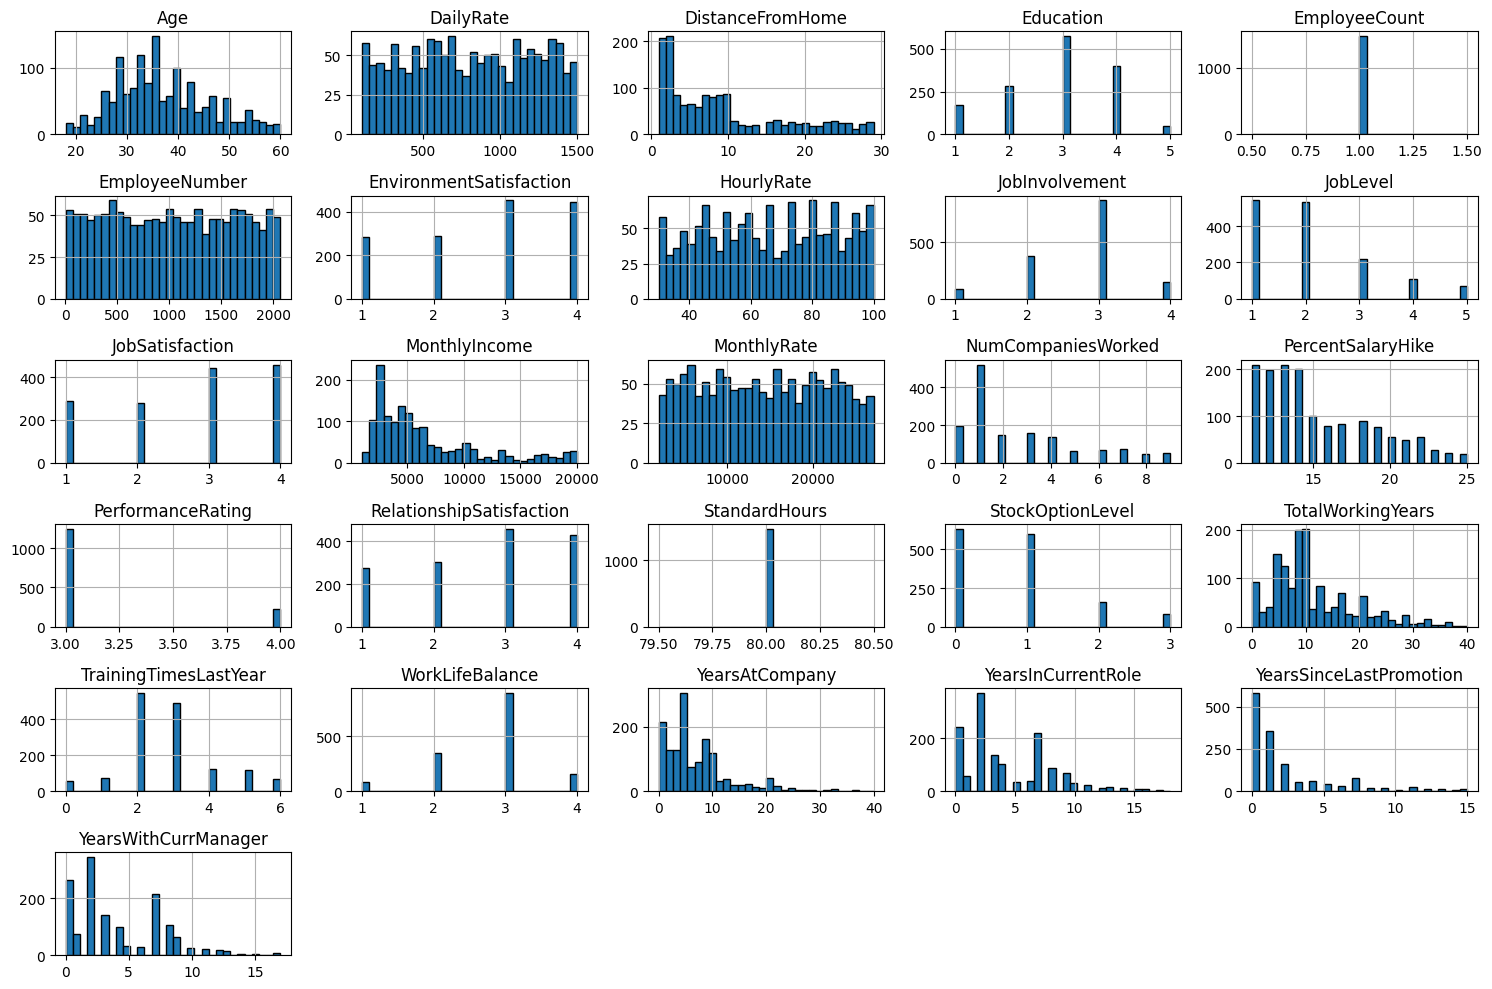

In [3]:
# Histograms for all numeric features
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number').columns
df[num_cols].hist(bins=30, figsize=(15, 10), edgecolor="black")
plt.tight_layout()
plt.show()


In [28]:
# Quick health check dataset

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


C:\Users\ramir\AppData\Local\Temp\ipykernel_35408\697927581.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No", "Yes"])
C:\Users\ramir\AppData\Local\Temp\ipykernel_35408\697927581.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No", "Yes"])
C:\Users\ramir\AppData\Local\Temp\ipykernel_35408\697927581.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No", "Yes"])
C:\Users\ramir\AppData\Local\Temp\ipykernel_35408\697927581.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No", "Yes"])
C:\Users\ramir\AppData\Local\Temp\ipykernel_35408\697927

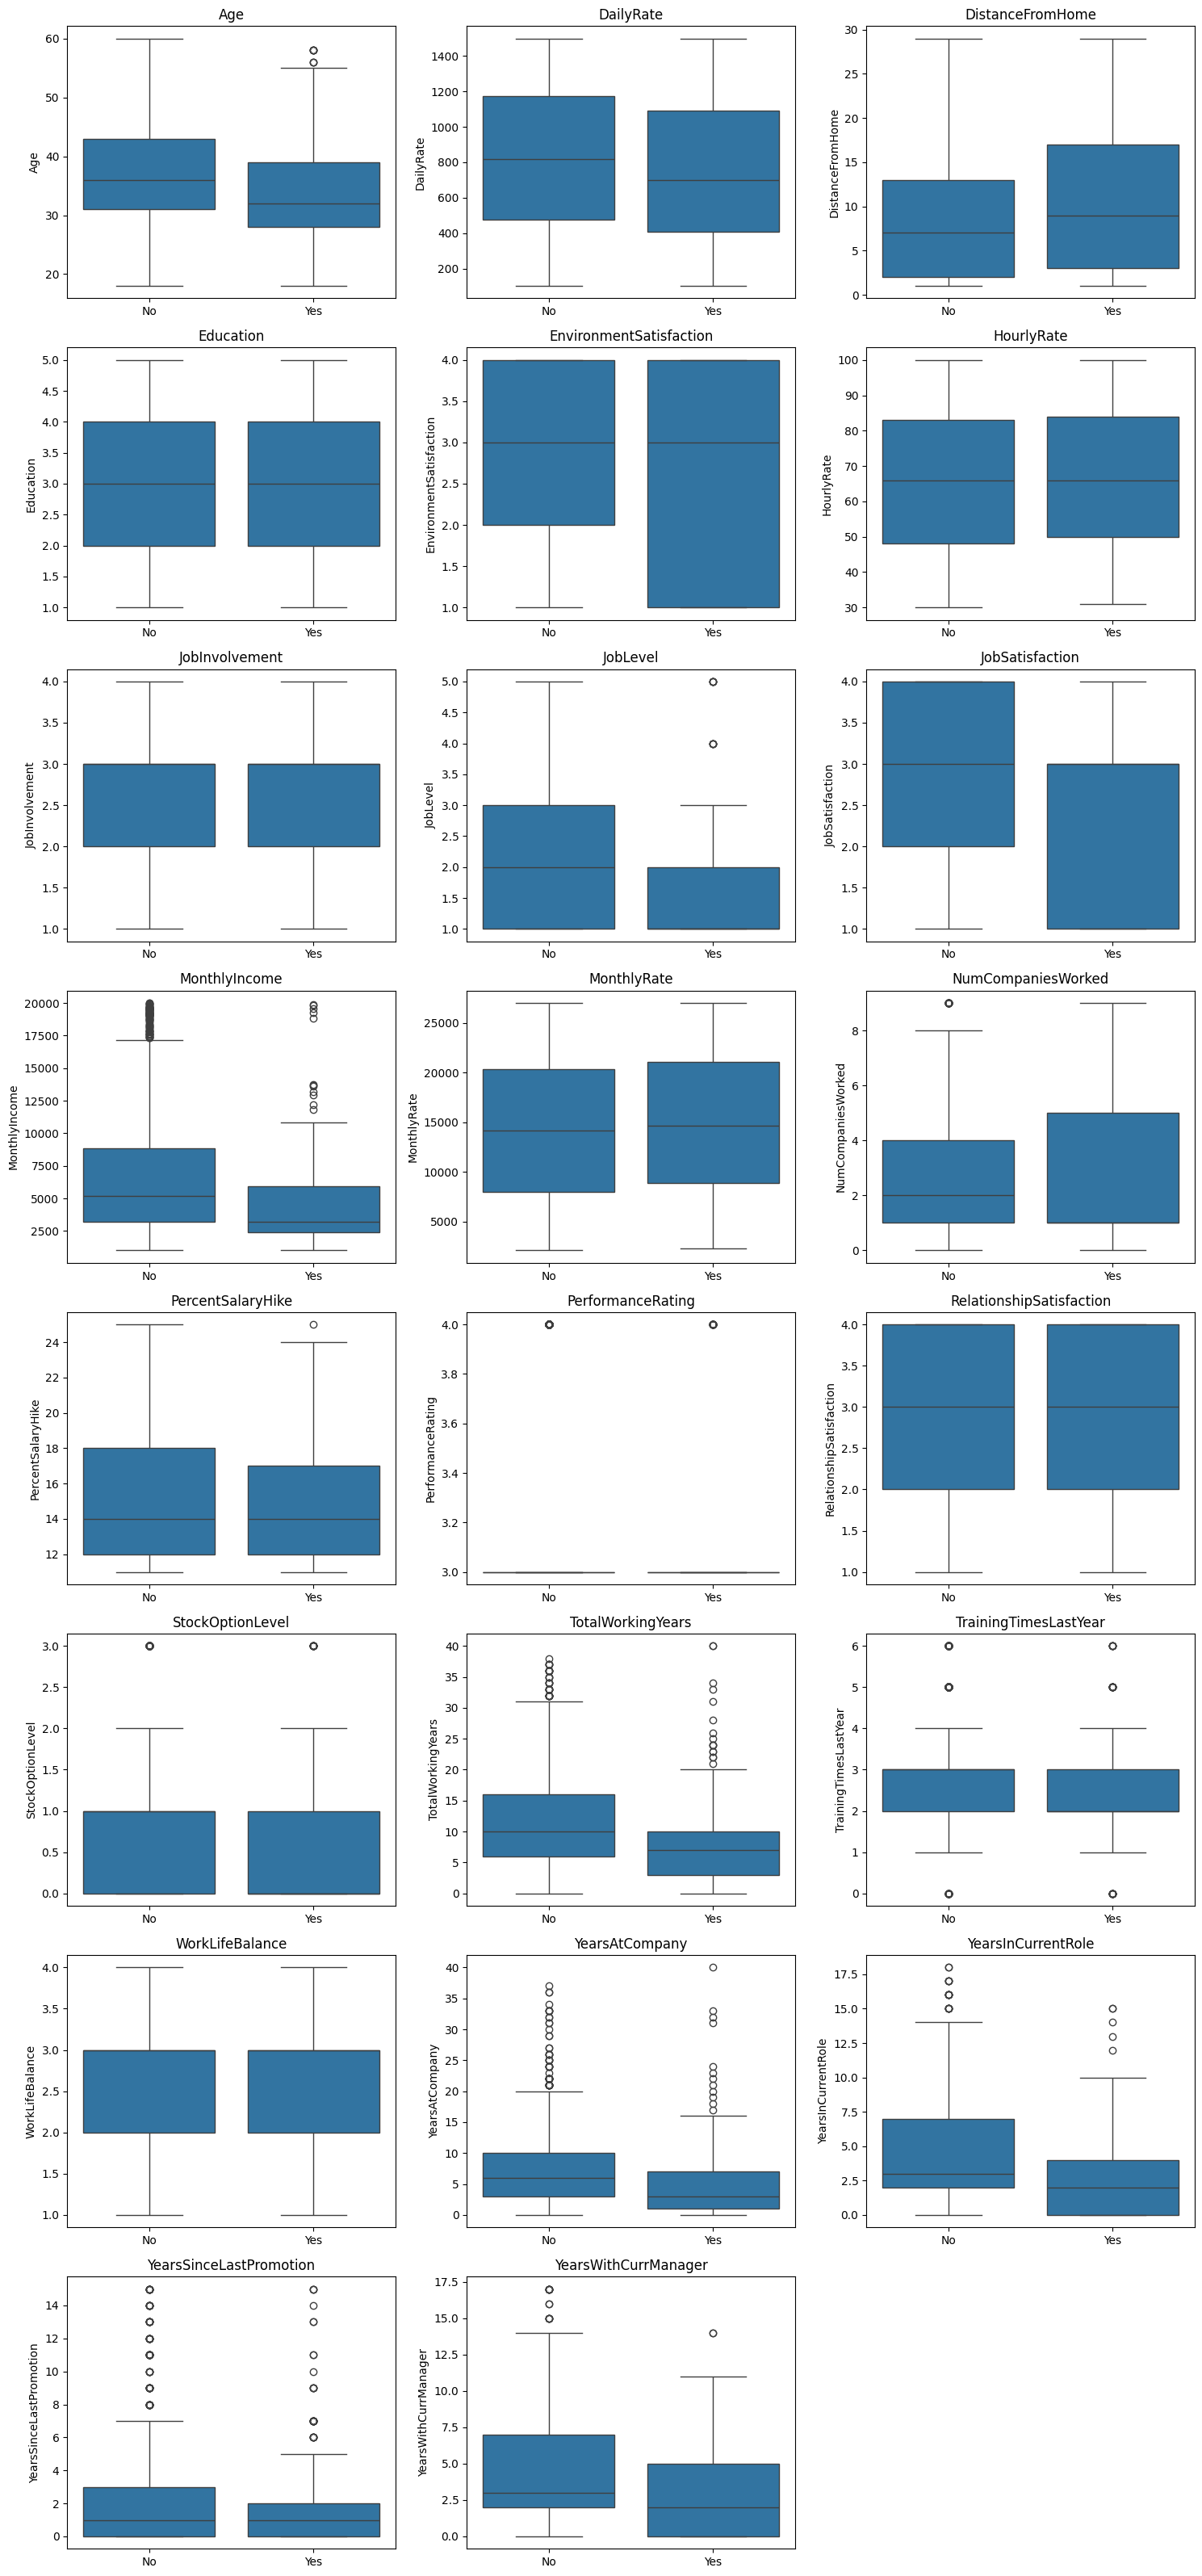

In [40]:
# Boxplots of numeric features split by Attrition
cols_to_plot = [c for c in num_cols if c not in ("EmployeeNumber", "EmployeeCount", "StandardHours", "Attrition")]
n = len(cols_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x="Attrition", y=col, data=df_corr, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_xticklabels(["No", "Yes"])

# remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Analysis of HR Attrition Dataset - Observations
1. The "Dead Weight" Columns (Zero Variance)
There are two columns in your data that provide zero information because every single row has the exact same value. You should drop these before doing any analysis or machine learning:

EmployeeCount: Every value is 1.

StandardHours: Every value is 80.

Why it matters: These columns have a standard deviation (std) of 0. They won't help a model predict attrition because they don't vary between employees who stay and those who leave.

2. ID Columns vs. Features
EmployeeNumber: This is just a unique identifier (ranging from 1 to 2068).

Warning: Do not include this in your correlation matrix or machine learning models. A model might accidentally "learn" that certain ID numbers are more likely to quit, which is just noise.

3. Outliers & Data Distribution (Skewness)
Looking at the quartiles (25%, 50%, 75%) vs. the max values, there are some highly "skewed" columns:

YearsAtCompany: The average employee has been there for 7 years, and 75% of staff have been there for 9 years or less. However, the max is 40 years. These "veterans" are outliers that might behave very differently from the rest of the group.

MonthlyIncome: The max is $19,999, while the median (50%) is only $4,919. This means you have a small group of very high earners (likely executives) pulling the average up.

YearsSinceLastPromotion: 75% of people were promoted within the last 3 years, but some haven't been promoted in 15 years. These are prime candidates for attrition analysis!

4. Scale Differences
Your features are on completely different scales. Age goes up to 60, but MonthlyRate goes up to 26,999.

Mindful Tip: If you plan to use models like KNN or SVM, you must scale your data (using StandardScaler or MinMaxScaler), or the MonthlyRate will completely overwhelm the Age or JobSatisfaction variables.

5. Categorical vs. Numerical
PerformanceRating: Notice the min is 3 and max is 4. This means in this dataset, no one received a "1" or "2" rating. The data is pre-filtered or everyone is a high performer.

Ordinal Data: Columns like Education, JobLevel, and EnvironmentSatisfaction are encoded as numbers (1-5), but they are actually Ordinal Categories. You should treat them as such when visualizing (e.g., use bar charts, not scatter plots).



C:\Users\ramir\AppData\Local\Temp\ipykernel_35408\3324057595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, ax=axs[i], palette='Set2')
C:\Users\ramir\AppData\Local\Temp\ipykernel_35408\3324057595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, ax=axs[i], palette='Set2')
C:\Users\ramir\AppData\Local\Temp\ipykernel_35408\3324057595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, ax=axs[i], palette='Set2')
C:\Users\ramir\AppData\Local\Te

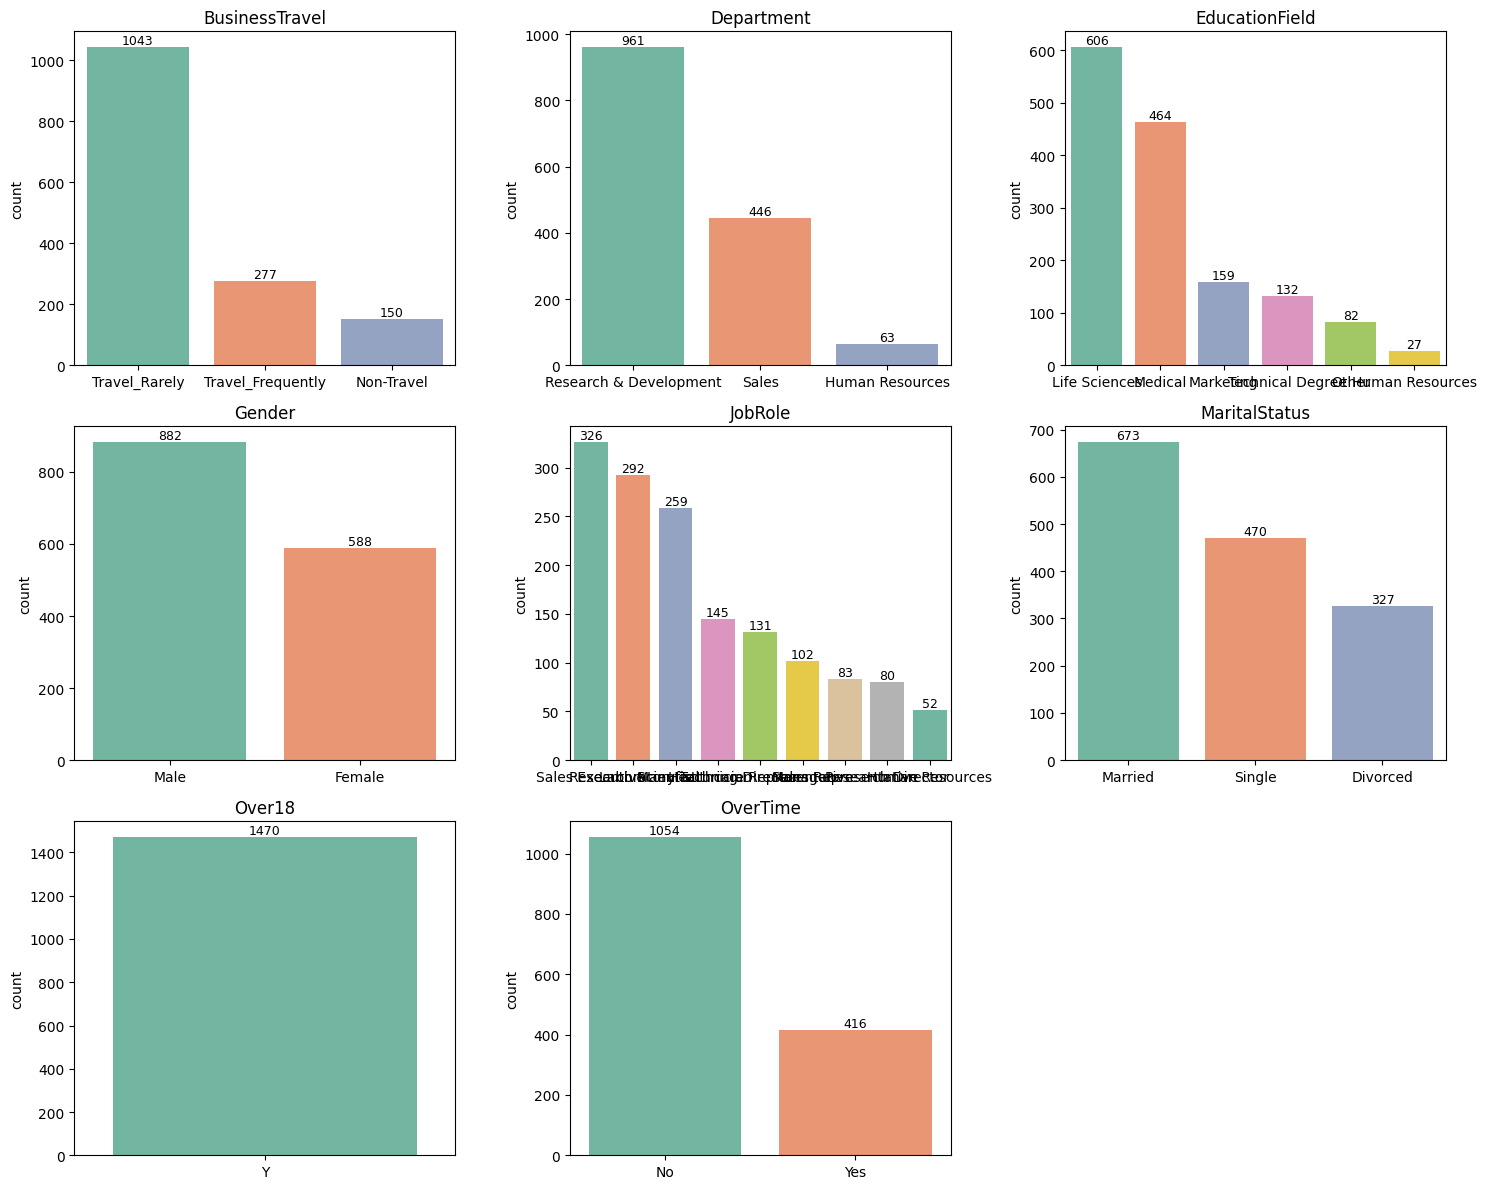

In [42]:
# Countplot for each categorical feature in cat_cols
n = len(cat_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axs = axs.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, ax=axs[i], palette='Set2')
    axs[i].set_title(col)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('count')
    for p in axs[i].patches:
        axs[i].annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=9)

# remove any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

# Analysis of HR Attrition Dataset - Categorical


1. The dataset is dominated by a few categories

R&D department
Life Sciences education
Laboratory Technicians and Sales Executives
Travel_Rarely

This means the dataset reflects a science‑heavy organization.

2. Some categories are too small for strong modeling

Human Resources
Manager roles
Non‑Travel employees

These may need grouping or careful interpretation.

3. OverTime, JobRole, BusinessTravel show strong separation when combined with Attrition. These are high‑value categorical predictors.

4. Attrition imbalance is visually obvious. Any countplot of Attrition confirms the need for:

resampling
class weights
or balanced algorithms

In [30]:
# Count employees who stayed vs left
attrition_counts = df['Attrition'].value_counts()
attrition_percent = df['Attrition'].value_counts(normalize=True) * 100
attrition_summary = pd.concat([attrition_counts, attrition_percent], axis=1)
attrition_summary.columns = ['count', 'percent']
print(attrition_summary)

           count    percent
Attrition                  
No          1233  83.877551
Yes          237  16.122449


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------------------- ---------------- 4.7/8.1 MB 23.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 24.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 21.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------------------------- -------- 5.5/7.0 MB 25.8 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 25.5 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- -----

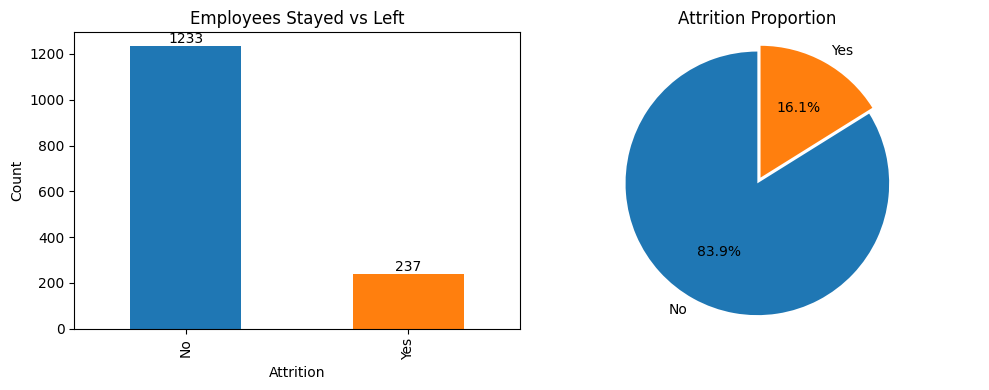

In [ ]:
#Distyribution of employees who stayed vs left
%pip install matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
attrition_counts.plot(kind='bar', ax=axes[0], color=['C0', 'C1'])
axes[0].set_title('Employees Stayed vs Left')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')

# Pie chart
axes[1].pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%',
            colors=['C0', 'C1'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Attrition Proportion')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
# Print unique values for each column
for col in df.columns:
    uniques = df[col].unique().tolist()
    print(f"{col} (dtype={df[col].dtype}) - {len(uniques)} unique values")
    print(uniques)
    print("-" * 80)

Age (dtype=int64) - 43 unique values
[41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 29, 31, 34, 28, 22, 53, 24, 21, 42, 44, 46, 39, 43, 50, 26, 48, 55, 45, 56, 23, 51, 40, 54, 58, 20, 25, 19, 57, 52, 47, 18, 60]
--------------------------------------------------------------------------------
Attrition (dtype=str) - 2 unique values
['Yes', 'No']
--------------------------------------------------------------------------------
BusinessTravel (dtype=str) - 3 unique values
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
--------------------------------------------------------------------------------
DailyRate (dtype=int64) - 886 unique values
[1102, 279, 1373, 1392, 591, 1005, 1324, 1358, 216, 1299, 809, 153, 670, 1346, 103, 1389, 334, 1123, 1219, 371, 673, 1218, 419, 391, 699, 1282, 1125, 691, 477, 705, 924, 1459, 125, 895, 813, 1273, 869, 890, 852, 1141, 464, 1240, 1357, 994, 721, 1360, 1065, 408, 1211, 1229, 626, 1434, 1488, 1097, 1443, 515, 853, 1142, 655, 1115, 427, 653, 989, 1435, 

# Summary for Analysis/Modeling
To predict Attrition, the most critical features to investigate would likely be MonthlyIncome, OverTime (if available), TotalWorkingYears, YearsAtCompany, and the Satisfaction scores. The lack of low performance ratings (1-2) makes performance a less useful differentiator compared to tenure and compensation.

# Columns to remove
1. Remove Constant Columns (Zero Variance)
These columns have the same value for every single row (standard deviation = 0). They provide no information for a model to learn from:

EmployeeCount: Every value is 1.
StandardHours: Every value is 80.

2. Remove Unique Identifiers
These columns act as a primary key or unique ID. While useful for lookups, they are noise for statistical analysis or predictive modeling:

EmployeeNumber: This is a sequential or random ID assigned to each person. Since it's unique to the individual, it won't help in identifying general patterns across the workforce.
Over18: Every value is 'Y'.
